In [6]:
import numpy as np
import matplotlib.pyplot as plt

from cifar10_data_preprocessing import *

In [7]:
data_dir = 'cifar-10-batches-py'

# Load cifar-10 dataset.
train_data, train_labels, test_data, test_labels, label_names = load_data(data_dir)

# Shuffle the train_data and divide into train_data and dev_data.
# num_dev indicates the number of image data in dev set.
dev_data, dev_labels, train_data, train_labels = split_dataset(train_data, train_labels, num_dev = 5000)

# Check the shape of train/dev/test data and number of classes.
print("Train data: ", train_data.shape)
print("Train labels: ", train_labels.shape)
print("Dev data: ", dev_data.shape)
print("Dev labels: ", dev_labels.shape)
print("Test data: ", test_data.shape)
print("Test labels: ", test_labels.shape)
print('Number of classes:', label_names.shape[0])

Train data:  (45000, 32, 32, 3)
Train labels:  (45000,)
Dev data:  (5000, 32, 32, 3)
Dev labels:  (5000,)
Test data:  (10000, 32, 32, 3)
Test labels:  (10000,)
Number of classes: 10


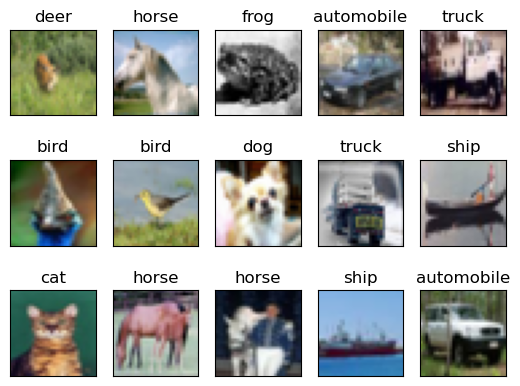

In [8]:
# Don't forget that the label_names and filesnames are in binary and need conversion if used.
classes = np.array(['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'])

# Display some random training images in a 3x5 grid
fig, ax = plt.subplots(3, 5)
for m in range(3):
    for n in range(5):
        idx = np.random.randint(0, train_data.shape[0])
        ax[m, n].set_title(classes[train_labels[idx]]) # display label
        ax[m, n].imshow(train_data[idx]) # display image data
        ax[m, n].get_xaxis().set_visible(False)
        ax[m, n].get_yaxis().set_visible(False)
plt.show()

In [9]:
# Convert label of each image data into one-hot vector(y). 
# Its length is the same as the number of classes.
y_train = one_hot_encoding(train_labels, classes)
y_dev = one_hot_encoding(dev_labels, classes)
y_test = one_hot_encoding(test_labels, classes)

print(y_train[0])
print(y_train.shape)


[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
(45000, 10)


In [10]:
# Normalize pixel values of input image from [0, 255] range to [0, 1] range.
x_train = normalize_image(train_data)
x_dev = normalize_image(dev_data)
x_test = normalize_image(test_data)

print(train_data[0]) # before normalization
print(x_train[0]) # after normalization

[[[ 51  31  33]
  [ 53  34  36]
  [ 56  37  39]
  ...
  [248 186  96]
  [248 182  99]
  [250 179  97]]

 [[ 51  32  34]
  [ 54  35  37]
  [ 56  37  39]
  ...
  [255 203  90]
  [255 196  93]
  [255 189  88]]

 [[ 56  37  39]
  [ 58  39  41]
  [ 59  40  42]
  ...
  [252 221 100]
  [253 219 101]
  [253 213  97]]

 ...

 [[199 183 209]
  [201 185 211]
  [209 193 212]
  ...
  [112  86  73]
  [124  91  77]
  [185 150 145]]

 [[209 193 216]
  [209 194 217]
  [213 198 213]
  ...
  [232 193 165]
  [237 193 151]
  [223 179 130]]

 [[223 210 226]
  [224 211 227]
  [226 214 224]
  ...
  [255 213 183]
  [254 210 157]
  [253 210 144]]]
[[[0.15702479 0.09049774 0.11415525]
  [0.16528926 0.1040724  0.12785388]
  [0.17768595 0.11764706 0.14155251]
  ...
  [0.97107438 0.7918552  0.40182648]
  [0.97107438 0.77375566 0.41552511]
  [0.97933884 0.760181   0.40639269]]

 [[0.15702479 0.09502262 0.11872146]
  [0.16942149 0.10859729 0.13242009]
  [0.17768595 0.11764706 0.14155251]
  ...
  [1.         0.8687782